# 01 · Exploración y limpieza de datos
Entrada: `data/raw/jugadores_raw.csv` (dataset bruto con incidencias)
Salida: `data/processed/jugadores_clean.csv` + figuras en `figures/`

Flujo: auditoría → reglas de limpieza → imputación → verificación → descriptivos → figuras.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..")          # el notebook vive en notebooks/
RAW  = ROOT / "data/raw/jugadores_raw.csv"
PROC = ROOT / "data/processed/jugadores_clean.csv"
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)

# Estilo pensado para LaTeX: fuente serif y tamaños para ancho final ~6.3 in
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "figure.dpi": 110,          # solo para verlo en el notebook
    "savefig.bbox": "tight",
})
ANCHO = 6.3   # in ≈ \textwidth en A4 con márgenes estándar

METRICAS = ["PrecisionPase", "VelReaccion", "Efectividad1v1", "VelSprint",
            "DistAltaInt", "AciertoRegate", "Recuperaciones", "TomaDecision"]

ETIQUETAS = {  # para ejes legibles en las figuras
    "PrecisionPase": "Precisión de pase (%)", "VelReaccion": "Vel. reacción (s)",
    "Efectividad1v1": "Efectividad 1v1 (%)", "VelSprint": "Vel. sprint (km/h)",
    "DistAltaInt": "Dist. alta int. (×100 m/90')", "AciertoRegate": "Acierto regate (%)",
    "Recuperaciones": "Recuperaciones /90'", "TomaDecision": "Toma de decisión (0–10)",
}

df = pd.read_csv(RAW)
df.head()

,Jugador,Posicion,Edad,PrecisionPase,VelReaccion,Efectividad1v1,VelSprint,DistAltaInt,AciertoRegate,Recuperaciones,TomaDecision,AltoPotencial
0,J01,Delantero,19,80.13,0.69,57.02,27.86,5.64,61.38,4.75,7.13,1
1,J02,Delantero,16,70.72,0.67,44.72,29.79,5.93,72.07,6.31,4.68,0
2,J03,Extremo,16,83.25,0.56,48.01,29.85,9.35,58.91,2.98,7.62,1
3,J04,Centrocampista,16,NaN,0.64,47.80,31.67,5.81,64.44,3.57,7.10,1
4,J05,Centrocampista,17,64.34,0.63,38.85,30.84,7.81,37.50,10.76,5.38,0


In [5]:
print("Dimensiones:", df.shape)
print("\nValores ausentes por columna:")
print(df[METRICAS].isna().sum())
print(f"\n% de celdas ausentes: {df[METRICAS].isna().sum().sum() / df[METRICAS].size:.1%}")

# ¿Qué jugadores concretos? Conviene mirarlos, no solo contarlos
df[df[METRICAS].isna().any(axis=1)]

Dimensiones: (40, 12)

Valores ausentes por columna:
PrecisionPase     1
VelReaccion       1
Efectividad1v1    1
VelSprint         0
DistAltaInt       0
AciertoRegate     0
Recuperaciones    0
TomaDecision      0
dtype: int64

% de celdas ausentes: 0.9%


,Jugador,Posicion,Edad,PrecisionPase,VelReaccion,Efectividad1v1,VelSprint,DistAltaInt,AciertoRegate,Recuperaciones,TomaDecision,AltoPotencial
3,J04,Centrocampista,16,NaN,0.64,47.80,31.67,5.81,64.44,3.57,7.10,1
11,J12,Extremo,19,83.44,0.68,NaN,27.30,7.34,44.74,7.18,6.77,0
22,J23,Extremo,19,86.56,NaN,48.08,26.09,6.31,59.77,6.96,7.55,1


In [6]:
# Rangos físicamente plausibles, definidos ANTES de mirar los datos
RANGOS = {
    "PrecisionPase":  (0, 100),
    "VelReaccion":    (0.30, 1.20),
    "Efectividad1v1": (0, 100),
    "VelSprint":      (24, 36),     # techo juvenil realista
    "DistAltaInt":    (2, 14),
    "AciertoRegate":  (0, 100),
    "Recuperaciones": (0, 20),
    "TomaDecision":   (0, 10),
}

violaciones = []
for col, (lo, hi) in RANGOS.items():
    mask = df[col].notna() & ~df[col].between(lo, hi)
    for _, fila in df[mask].iterrows():
        violaciones.append((fila["Jugador"], col, fila[col], f"[{lo}, {hi}]"))

pd.DataFrame(violaciones, columns=["Jugador", "Variable", "Valor", "Rango válido"])

,Jugador,Variable,Valor,Rango válido
0,J08,VelSprint,41.2,"[24, 36]"


## Decisiones de limpieza
1. **VelSprint = 41.2 km/h (J08)**: fuera del rango plausible → error de tracking
   (confusión de identidades). Se recodifica como NaN.
2. **NaN (4 celdas tras el paso anterior, <3% del total)**: imputación con la
   **mediana de la posición** del jugador. Robusta frente a extremos y respeta
   el perfil de cada demarcación. Se descarta eliminar filas (perderíamos ~10% de n=40).

In [7]:
dfc = df.copy()

# Regla 1: valores fuera de rango -> NaN
for col, (lo, hi) in RANGOS.items():
    fuera = dfc[col].notna() & ~dfc[col].between(lo, hi)
    dfc.loc[fuera, col] = np.nan

# Comparativa didáctica ANTES de imputar: mediana global vs por posición
pendientes = dfc[dfc[METRICAS].isna().any(axis=1)]
for _, fila in pendientes.iterrows():
    for col in METRICAS:
        if pd.isna(fila[col]):
            glob = dfc[col].median()
            pos  = dfc.loc[dfc.Posicion == fila.Posicion, col].median()
            print(f"{fila.Jugador} ({fila.Posicion}) · {col}: "
                  f"global={glob:.2f} | por posición={pos:.2f}")

# Regla 2: imputación por mediana de posición
for col in METRICAS:
    dfc[col] = dfc[col].fillna(dfc.groupby("Posicion")[col].transform("median"))

J04 (Centrocampista) · PrecisionPase: global=77.88 | por posición=75.00
J08 (Extremo) · VelSprint: global=29.27 | por posición=28.72
J12 (Extremo) · Efectividad1v1: global=48.27 | por posición=48.27
J23 (Extremo) · VelReaccion: global=0.63 | por posición=0.59


In [8]:
assert dfc[METRICAS].isna().sum().sum() == 0, "Quedan NaN"
for col, (lo, hi) in RANGOS.items():
    assert dfc[col].between(lo, hi).all(), f"{col} fuera de rango"
assert len(dfc) == len(df), "Se han perdido filas"

PROC.parent.mkdir(exist_ok=True, parents=True)
dfc.to_csv(PROC, index=False)
print("OK →", PROC)

OK → ..\data\processed\jugadores_clean.csv


In [9]:
desc = dfc[METRICAS].describe().T[["mean", "std", "min", "50%", "max"]]
desc.columns = ["Media", "Desv. típ.", "Mín.", "Mediana", "Máx."]
desc.index = [ETIQUETAS[i] for i in desc.index]
desc = desc.round(2)

# Exporta la tabla directamente a LaTeX: nada de copiar números a mano
(ROOT / "informe/tablas").mkdir(exist_ok=True, parents=True)
desc.style.format(precision=2).to_latex(
    ROOT / "informe/tablas/tab_descriptivos.tex", hrules=True)
desc

,Media,Desv. típ.,Mín.,Mediana,Máx.
Precisión de pase (%),78.03,5.71,64.34,77.76,92.99
Vel. reacción (s),0.62,0.07,0.47,0.63,0.75
Efectividad 1v1 (%),49.37,8.66,33.00,48.27,69.62
Vel. sprint (km/h),29.41,1.66,26.09,29.26,33.50
Dist. alta int. (×100 m/90'),6.91,1.14,5.16,6.77,9.35
Acierto regate (%),56.70,9.97,36.53,56.06,83.17
Recuperaciones /90',6.66,2.16,2.98,6.40,12.00
Toma de decisión (0–10),6.66,1.10,3.78,6.72,8.52


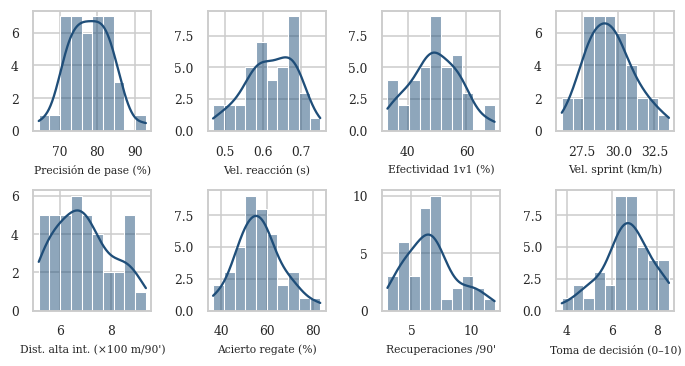

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(ANCHO, 3.4))
for ax, col in zip(axes.ravel(), METRICAS):
    sns.histplot(dfc[col], bins=10, kde=True, ax=ax, color="#1f4e79")
    ax.set_xlabel(ETIQUETAS[col], fontsize=7)
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGS / "fig1_distribuciones.pdf")

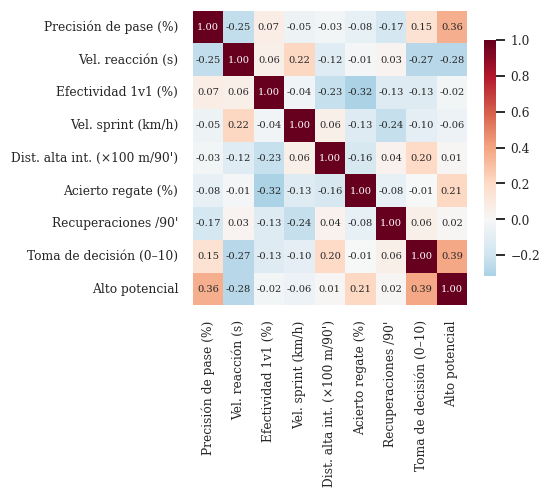

In [11]:
fig, ax = plt.subplots(figsize=(ANCHO * 0.8, 4.6))
corr = dfc[METRICAS + ["AltoPotencial"]].corr()
nombres = [ETIQUETAS.get(c, "Alto potencial") for c in corr.columns]
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            xticklabels=nombres, yticklabels=nombres,
            annot_kws={"size": 6.5}, cbar_kws={"shrink": 0.8}, ax=ax)
fig.tight_layout()
fig.savefig(FIGS / "fig2_correlaciones.pdf")

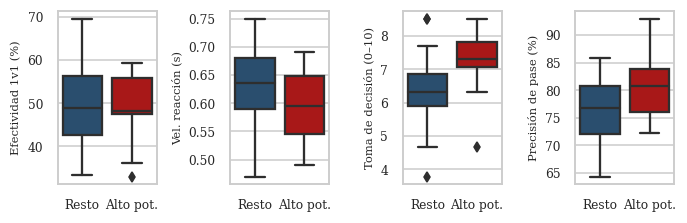

In [15]:
clave = ["Efectividad1v1", "VelReaccion", "TomaDecision", "PrecisionPase"]
fig, axes = plt.subplots(1, 4, figsize=(ANCHO, 2.1))
for ax, col in zip(axes, clave):
    sns.boxplot(data=dfc, x="AltoPotencial", y=col,
                palette=["#1f4e79", "#c00000"], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Resto", "Alto pot."])
    ax.set_xlabel(""); ax.set_ylabel(ETIQUETAS[col], fontsize=7.5)
fig.tight_layout()
fig.savefig(FIGS / "fig3_grupos.pdf")

In [16]:
dfc.groupby("AltoPotencial")[METRICAS].mean().round(2).T

AltoPotencial,0,1
PrecisionPase,76.54,80.79
VelReaccion,0.63,0.60
Efectividad1v1,49.53,49.09
VelSprint,29.48,29.29
DistAltaInt,6.90,6.92
AciertoRegate,55.18,59.53
Recuperaciones,6.63,6.71
TomaDecision,6.35,7.23
